<a href="https://colab.research.google.com/github/RohanBolle/BigCrunch/blob/main/H0_plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import scipy as sp
from sympy import lambdify
import cmath
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from scipy.integrate import quad

In [11]:
# Constants
G_0 = 1
H_0 = 1 / 13.8
c = 1
Omega_0_m = 1  # normalized mass density
omega_r = 0.0
omega_lambda = 0.0
omega_0 = omega_lambda + omega_r + Omega_0_m


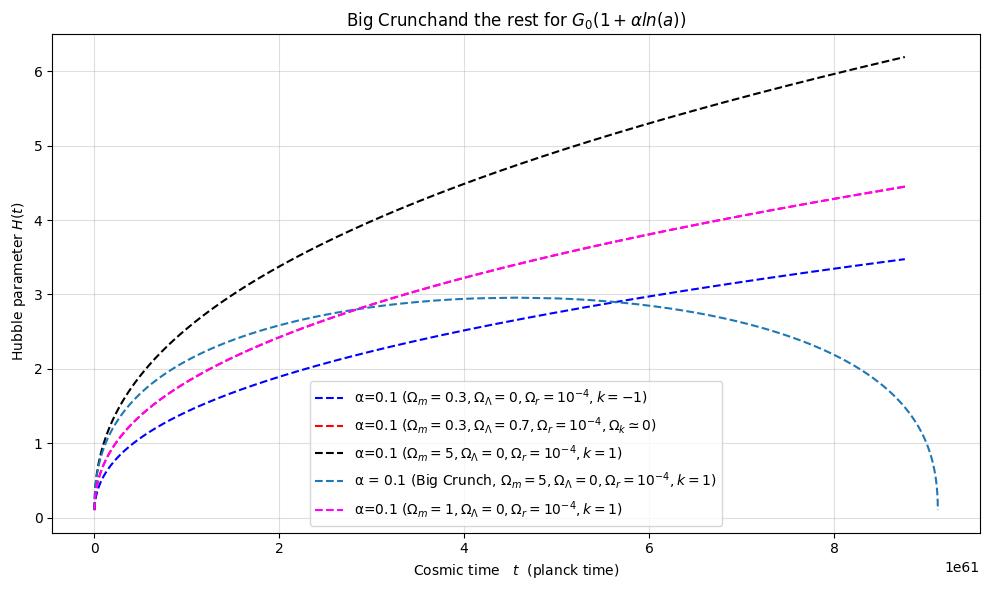

In [26]:
def func_0(a, alpha):  # G_star
    return G_0 * alpha + G_0 * (alpha * np.log(a) + 1)

def func_1(a, alpha):  # G1_star
    term1 = G_0**2 * (alpha * np.log(a) + 1)**2
    bracket = (G_0**2 * alpha**2 * np.log(a)) / (2 * a**2) - (G_0**2 * alpha**2) / (4 * a**2) + (G_0**2 * alpha) / (2 * a**2)
    term2 = a**2 * bracket
    return term1 - term2

def func_2(a, alpha):  # G2_star
    term1 = G_0**2 * (alpha * np.log(a) + 1)**2
    bracket = (G_0**2 * alpha**2 * np.log(a)) / (3 * a**3) - (G_0**2 * alpha**2) / (9 * a**3) + (G_0**2 * alpha) / (3 * a**3)
    term2 = 2 * a**3 * bracket
    return term1 - term2

# Alpha values to test
alpha_values = [0.1]
colors = ['blue', 'red', 'black', 'magenta'] # Corrected color order to match scenarios
t_i = 0.01
t_f = 150.0
y_i = 0.1


plt.figure(figsize=(10, 6))
Gyr_to_tP = 3.15e16 / 5.39e-44  # ≈ 5.84e59

def std_friedmann(t, a, Omega_m, Omega_r, Omega_l, Omega_k):
    return a * H_0 * (
        Omega_m / a**3 + (1 - Omega_m) / a**2 + Omega_r / a**4 + Omega_l
    )**0.5

# Solve modified Friedmann for each alpha

scenarios = [
    {"Omega_m": 0.3, "Omega_r": 1e-4, "Omega_l": 0.0, "color": "blue", "label": r"$\Omega_m=0.3, \Omega_\Lambda=0, \Omega_r=10^{-4}, k=-1$"},
    {"Omega_m": 0.3, "Omega_r": 1e-4, "Omega_l": 0.7, "color": "red", "label": r"$\Omega_m=0.3, \Omega_\Lambda=0.7, \Omega_r=10^{-4}, \Omega_k \simeq 0$"},
    {"Omega_m": 5.0, "Omega_r": 1e-4, "Omega_l": 0.0, "color": "black", "label": r"$\Omega_m=5, \Omega_\Lambda=0, \Omega_r=10^{-4}, k=1$"},
    {"Omega_m": 1.0, "Omega_r": 1e-4, "Omega_l": 0.0, "color": "magenta", "label": r"$\Omega_m=1, \Omega_\Lambda=0, \Omega_r=10^{-4}, k=1$"},
]

for scenario in scenarios:
    scenario["omega_0"] = scenario["Omega_m"] + scenario["Omega_r"] + scenario["Omega_l"] # Add omega_0 to the dictionary
    Omega_m = scenario["Omega_m"]
    Omega_r = scenario["Omega_r"]
    Omega_l = scenario["Omega_l"]
    omega_0 = scenario["omega_0"]
    Omega_k = 1.0 - omega_0  # Geometry curvature

  # # Standard Friedmann solution
  #   sol_std = solve_ivp(
  #       lambda t, a: std_friedmann(t, a, Omega_m, Omega_r, Omega_l, Omega_k),
  #       [t_i, t_f], [y_i], t_eval=np.linspace(t_i, t_f, 1000),
  #       method='LSODA', rtol=1e-5)

  #   plt.plot(sol_std.t * Gyr_to_tP, sol_std.y[0], '-',label='Standard Friedmann')
  #   # Solve modified Friedmann and Big Crunch for each alpha

    # crunch_results_pos = [] # Clear the list before the loop  # This should be outside the scenario loop
    for i, alpha in enumerate(alpha_values):
        sol = solve_ivp(
            lambda t, a: H_0 * (
                (omega_0 * func_0(a, alpha)) / (a**3 * G_0) +
                (omega_0**2 * H_0**2 * func_1(a, alpha)) / (G_0 * a**6 * 2 * c**2) +
                (omega_0 * func_2(a, alpha)) / (G_0 * c**3 * a**3)
            )**0.5,
            [t_i, t_f], [y_i], t_eval=np.linspace(t_i, t_f, 1000),
            method='LSODA', rtol=1e-5
        )
        # print(f"Scenario: {scenario['label']}")
        # print(f"  solve_ivp success: {sol.success}")
        # print(f"  final a: {sol.y[0][-1]}")
        # print(f"  max a: {np.max(sol.y[0])}")
        # print(f"  time range: {sol.t[0]} to {sol.t[-1]}")

        plt.plot(sol.t * Gyr_to_tP, sol.y[0], '--', label=f'α={alpha} ({scenario["label"]})', color=scenario['color'])

          #------------------------------ BIG CRUNCH -----------------------------------
        def E2(a):
            term0 = Omega_k / a**2
            term1 = (omega_0 * func_0(a, alpha)) / (a**3 * G_0)
            term2 = (omega_0**2 * H_0**2 * func_1(a, alpha)) / (G_0 * a**6 * 2 * c**2)
            term3 = (omega_0 * func_2(a, alpha)) / (G_0 * c**3 * a**3)
            return term0 + term1 + term2 + term3

        a_vals = np.geomspace(0.1, 20, 1000)
        e2_vals = np.array([E2(a) for a in a_vals])
        sign_changes = np.where(np.diff(np.signbit(e2_vals)))[0]

        if len(sign_changes) > 0:
            idx = sign_changes[0]
            bracket = [a_vals[idx], a_vals[idx + 1]]
            result = root_scalar(lambda x: E2(x), bracket=bracket, method='brentq')
            a_max = result.root

            def dt_da(a): return 1.0 / (np.sqrt(E2(a)))

            # Expand from Big Bang (a = 0.1) to a_max
            a_grid = np.geomspace(0.1, a_max, 1000)
            t_grid = np.array([quad(dt_da, 0.1, a)[0] for a in a_grid])
            t_max = t_grid[-1]
            a_full = np.concatenate([a_grid, a_grid[::-1]])
            t_full = np.concatenate([t_grid, t_max + (t_max - t_grid[::-1])])
            t_full_gyr = t_full * 14  # Convert to billions of years

            plt.plot(t_full_gyr * Gyr_to_tP, a_full ,'--', label=f"α = {alpha} (Big Crunch, {scenario['label']})") # Added scenario label and color and corrected conversion_factor

plt.xlabel(r"Cosmic time   $t$  (planck time)")
plt.ylabel(r" Hubble parameter $H(t)$")
plt.title("Big Crunchand the rest for $G_{0}(1+\\alpha ln(a))$")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
# plt.yscale('log')
plt.savefig("big_crunch_alpha.png")
plt.show()


# print(sol.t * Gyr_to_tP)
# print (t_full_gyr*conversion_factor)

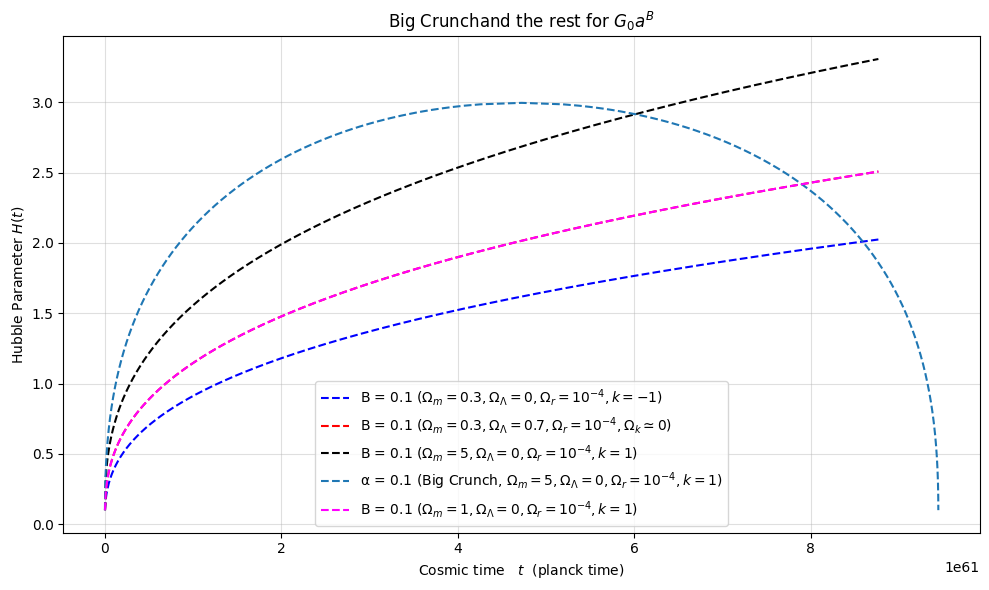

In [27]:
# Define G_star functions (piecewise logic)
def func1_0(r, B):
    if np.isclose(B, 1):
        return -B * G_0 * r * np.log(r) + G_0 * r**B
    else:
        return -B * G_0 * r * (r**B / (B * r - r)) + G_0 * r**B

def func1_1(r, B):
    if np.isclose(B, 1):
        return B * G_0**2 * r**2 * np.log(r) + G_0**2 * r**(2*B)
    else:
        return B * G_0**2 * r**2 * (r**(2*B) / (2 * B * r**2 - 2 * r**2)) + G_0**2 * r**(2*B)

def func1_2(r, B):
    if np.isclose(B, 1.5):
        return 2 * B * G_0**2 * r**3 * np.log(r) + G_0**2 * r**(2*B)
    else:
        return 2 * B * G_0**2 * r**3 * (r**(2*B) / (2 * B * r**3 - 3 * r**3)) + G_0**2 * r**(2*B)

# Alpha values to test
B_vals = [0.1]
colors = ['blue', 'red', 'black', 'magenta'] # Corrected color order to match scenarios
l = 1
z = 1
t_i = 0.01
t_f = 150.0

plt.figure(figsize=(10, 6))
Gyr_to_tP = 3.15e16 / 5.39e-44  # ≈ 5.84e59

def std_friedmann(t, a, Omega_m, Omega_r, Omega_l, Omega_k):
    return a * H_0 * (
        Omega_m / a**3 + (1 - Omega_m) / a**2 + Omega_r / a**4 + Omega_l
    )**0.5

# Solve modified Friedmann for each alpha

scenarios = [
    {"Omega_m": 0.3, "Omega_r": 1e-4, "Omega_l": 0.0, "color": "blue", "label": r"$\Omega_m=0.3, \Omega_\Lambda=0, \Omega_r=10^{-4}, k=-1$"},
    {"Omega_m": 0.3, "Omega_r": 1e-4, "Omega_l": 0.7, "color": "red", "label": r"$\Omega_m=0.3, \Omega_\Lambda=0.7, \Omega_r=10^{-4}, \Omega_k \simeq 0$"},
    {"Omega_m": 5.0, "Omega_r": 1e-4, "Omega_l": 0.0, "color": "black", "label": r"$\Omega_m=5, \Omega_\Lambda=0, \Omega_r=10^{-4}, k=1$"},
    {"Omega_m": 1.0, "Omega_r": 1e-4, "Omega_l": 0.0, "color": "magenta", "label": r"$\Omega_m=1, \Omega_\Lambda=0, \Omega_r=10^{-4}, k=1$"},
]

for scenario in scenarios:
    scenario["omega_0"] = scenario["Omega_m"] + scenario["Omega_r"] + scenario["Omega_l"] # Add omega_0 to the dictionary
    Omega_m = scenario["Omega_m"]
    Omega_r = scenario["Omega_r"]
    Omega_l = scenario["Omega_l"]
    omega_0 = scenario["omega_0"]
    Omega_k = 1.0 - omega_0  # Geometry curvature

    for i, B in enumerate(B_vals):
        sol_1 = solve_ivp(lambda t, r: H_0 * (
            (omega_0 * func1_0(r, B)) / (r**3 * G_0) +
             (l * omega_0**2 * H_0**2 * func1_1(r, B)) / (G_0**2 * r**6 * 2 * c**2) -
             (z * omega_0 * func1_2(r, B)) / (G_0 * c**3 * r**3))**0.5,
             [t_i, t_f], [y_i], t_eval=np.linspace(t_i, t_f, 1000),method='RK45', rtol=1e-5
          )
        plt.plot(sol_1.t * Gyr_to_tP, sol_1.y[0], '--', label=f'B = {B} ({scenario["label"]})', color = scenario['color'])

            # -------------------------xxxBIG CRUNCHxxx------------------------------------------

        def E2_1(a):
          term0 = Omega_k / a**2
          term1 = (omega_0 * func1_0(a, B)) / (a**3 * G_0)
          term2 = (omega_0**2 * H_0**2 * func1_1(a, B)) / (G_0 * a**6 * 2 * c**2)
          term3 = (omega_0 * func1_2(a, B)) / (G_0 * c**3 * a**3)
          return term0 + term1 + term2 + term3

        a_vals = np.geomspace(0.1, 20, 1000)
        e2_vals = np.array([E2_1(a) for a in a_vals])
        sign_changes = np.where(np.diff(np.signbit(e2_vals)))[0]

        if len(sign_changes) > 0:
            idx = sign_changes[0]
            bracket = [a_vals[idx], a_vals[idx + 1]]
            result = root_scalar(lambda x: E2_1(x), bracket=bracket, method='brentq')
            a_max = result.root

            def dt1_da(a): return 1.0 / (np.sqrt(E2_1(a)))

            # Integrate time from early a ~ 1e-5 instead of a = 1
            a1_grid = np.geomspace(0.1, a_max, 1000)
            t1_grid = np.array([quad(dt1_da, 0.1, a)[0] for a in a1_grid])
            t_max = t1_grid[-1]
            a1_full = np.concatenate([a1_grid, a1_grid[::-1]])
            t1_full = np.concatenate([t1_grid, t_max + (t_max - t1_grid[::-1])])
            t1_full_gyr = t1_full * 14  # Convert to billions of years
            plt.plot(t1_full_gyr * Gyr_to_tP, a1_full ,'--', label=f"α = {B} (Big Crunch, {scenario['label']})")

plt.xlabel(r"Cosmic time   $t$  (planck time)")
plt.ylabel(r"Hubble Parameter $H(t)$")
plt.title("Big Crunchand the rest for $G_{0}a^{B}$")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
# plt.yscale('log')
plt.savefig("big_crunch_B.png")
plt.show()

# print(t1_full_gyr, a1_full)